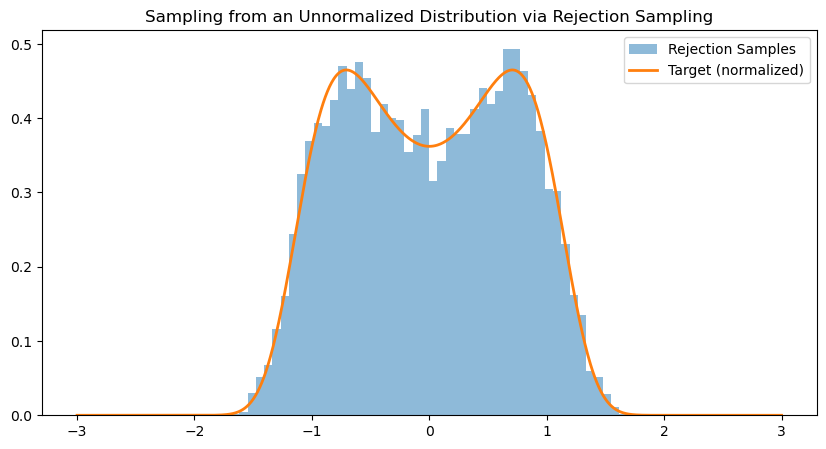

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the unnormalized target distribution f(x)
def f(x):
    return np.exp(-x**4 + x**2)

# Proposal distribution: Normal with larger variance
q = lambda x: (1 / (np.sqrt(2 * np.pi * 1.5**2))) * np.exp(-x**2 / (2 * 1.5**2))
proposal_sampler = lambda n: np.random.normal(loc=0, scale=1.5, size=n)

# Find M so that f(x) <= M * q(x)
x_vals = np.linspace(-3, 3, 1000)
M = np.max(f(x_vals) / q(x_vals))

# Rejection sampling
samples = []
N = 10000
while len(samples) < N:
    x_candidate = proposal_sampler(1)[0]
    accept_prob = f(x_candidate) / (M * q(x_candidate))
    if np.random.rand() < accept_prob:
        samples.append(x_candidate)

# Plotting
plt.figure(figsize=(10, 5))
plt.hist(samples, bins=50, density=True, alpha=0.5, label="Rejection Samples")
plt.plot(x_vals, f(x_vals) / np.trapz(f(x_vals), x_vals), label="Target (normalized)", linewidth=2)
plt.title("Sampling from an Unnormalized Distribution via Rejection Sampling")
plt.legend()
plt.show()
